In [1]:
import pandas as pd
import pyarrow as pa
import numpy as np
import matplotlib.pyplot as plt
import shap

c:\Users\staeh\git\stonksai\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
data = pd.read_csv("data_UBS.csv")
data = data.set_index("timestamp")
data.sort_index(ascending=False).head()

,0QKI.LON,0QLR.LON,NSRGY,RHO6.FRK,ABBNY,0QP2.LON,0QKY.LON,0QNO.LON,0QPS.LON,0Z4C.LON,...,US5Y,US10Y,US30Y,YC_Slope,Stress Index,FEDFUNDS,UNRATE,Median CPI,UMCSENT,USEPUINDXD
timestamp,,,,,,,,,,,,,,,,,,,,,
2025-11-26,581.6965,104.8216,98.64,41.685,70.39,574.2851,74.4687,541.0258,3342.334,158.5933,...,3.55,4.01,4.67,0.55,-0.5071,4.09,4.4,2.384737,53.6,386.20
2025-11-25,583.2849,104.5367,98.91,41.530,69.13,568.6862,74.5000,538.6921,3322.671,151.6523,...,3.61,4.04,4.68,0.58,-0.5071,4.09,4.4,2.384737,53.6,327.22
2025-11-24,580.5000,103.0000,99.51,41.760,68.56,565.2000,72.2708,534.8000,3347.135,151.9000,...,3.62,4.06,4.71,0.58,-0.5071,4.09,4.4,2.384737,53.6,327.22
2025-11-21,580.5000,101.8550,100.07,41.900,67.79,558.1000,70.4600,534.2808,3309.500,149.3250,...,3.68,4.10,4.73,0.55,-0.5071,4.09,4.4,2.384737,53.6,490.22
2025-11-20,575.7500,99.9250,98.09,42.140,67.56,562.6000,72.1600,530.0000,3261.500,151.4750,...,3.71,4.13,4.75,0.55,-0.5071,4.09,4.4,2.384737,53.6,279.64


In [3]:
data.columns

Index(['0QKI.LON', '0QLR.LON', 'NSRGY', 'RHO6.FRK', 'ABBNY', '0QP2.LON',
       '0QKY.LON', '0QNO.LON', '0QPS.LON', '0Z4C.LON',
       ...
       'US5Y', 'US10Y', 'US30Y', 'YC_Slope', 'Stress Index', 'FEDFUNDS',
       'UNRATE', 'Median CPI', 'UMCSENT', 'USEPUINDXD'],
      dtype='object', length=141)

# Target and Feature Selection

## Target

In [4]:
target_col = "ctc_vol_shifted"


# y = data["ctc_vol_shifted"]
y = data[target_col]
y.head()

timestamp
2015-03-18    0.015413
2015-03-20    0.018327
2015-03-24    0.016151
2015-04-01    0.015196
2015-04-02    0.014950
Name: ctc_vol_shifted, dtype: float64

## Feature

In [5]:
#cols_to_drop = ["ctc_vol_shifted", "parkinson_vol_shifted", "ctc_vol", "parkinson_vol","upper_wick_ratio", "lower_wick_ratio", "Real Lower Band", "Real Middle Band", "Real Upper Band"]
feature_cols = ["open", "high", "low", "close", "volume"]

X = data[feature_cols]
X.head()

,open,high,low,close,volume
timestamp,,,,,
2015-03-18,17.91,18.3300,17.890,18.27,2022231
2015-03-20,18.69,18.8400,18.580,18.70,1617912
2015-03-24,19.22,19.2983,19.110,19.14,1873740
2015-04-01,19.15,19.1900,19.010,19.14,950114
2015-04-02,19.32,19.3700,19.265,19.32,996015


In [6]:
display(data.sort_index(ascending=True).head())

,0QKI.LON,0QLR.LON,NSRGY,RHO6.FRK,ABBNY,0QP2.LON,0QKY.LON,0QNO.LON,0QPS.LON,0Z4C.LON,...,US5Y,US10Y,US30Y,YC_Slope,Stress Index,FEDFUNDS,UNRATE,Median CPI,UMCSENT,USEPUINDXD
timestamp,,,,,,,,,,,,,,,,,,,,,
2015-03-18,566.750,82.5670,77.975,31.150,21.04,325.0000,75.314700,116.432212,1840.790698,3638.803314,...,1.56,2.06,2.61,1.36,-0.2754,0.11,5.7,1.94753,98.1,37.41
2015-03-20,569.000,83.4907,78.070,32.351,21.41,329.7500,75.126538,116.907404,1846.000000,3656.165176,...,1.48,1.98,2.54,1.33,-0.1217,0.11,5.7,1.94753,98.1,37.15
2015-03-24,578.250,82.3177,78.101,32.525,21.64,331.9000,74.750214,117.857788,1786.900000,3690.888900,...,1.41,1.92,2.51,1.30,-0.1217,0.11,5.7,1.94753,98.1,35.63
2015-04-01,562.800,81.0212,75.790,32.105,21.38,327.8050,73.997567,119.758558,1758.142000,3604.666614,...,1.37,1.94,2.54,1.32,-0.1486,0.11,5.7,1.94753,98.1,91.47
2015-04-02,568.475,80.4326,76.400,31.805,21.49,328.6527,73.903486,119.996154,1743.900000,3593.888829,...,1.32,1.87,2.47,1.37,-0.2129,0.12,5.7,1.94753,98.1,37.66


# Models

## Linear Regression

In [7]:
split = int(len(data) * 0.8)   # 80% train, 20% test

X_train = X.iloc[:split]
X_test  = X.iloc[split:]

y_train = y.iloc[:split]
y_test  = y.iloc[split:]
print(len(X_train))
print(len(X_test))
print(len(y_train))
print(len(y_test))

1720
431
1720
431


In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [9]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


low       0.175228
high      0.132143
close     0.031580
open      0.009485
volume    0.003535
dtype: float64


<Axes: >

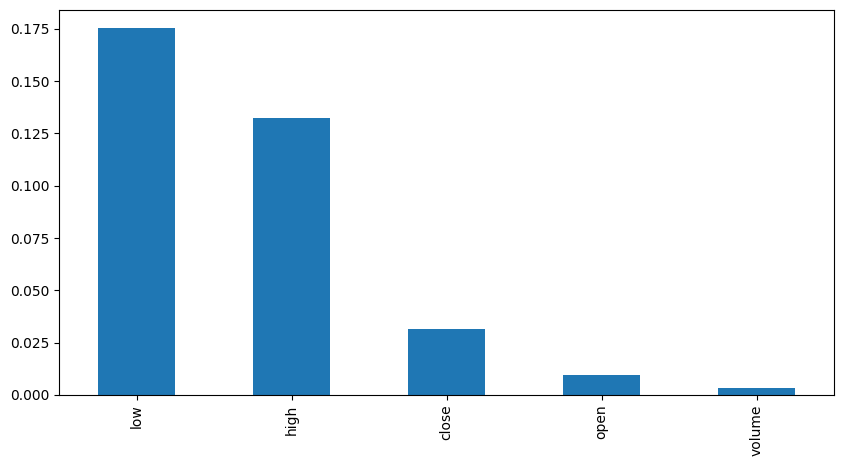

In [10]:
coefs = pd.Series(lr.coef_, index=X_train.columns)
importance = coefs.abs().sort_values(ascending=False)
print(importance)
importance.plot(kind="bar", figsize=(10,5))

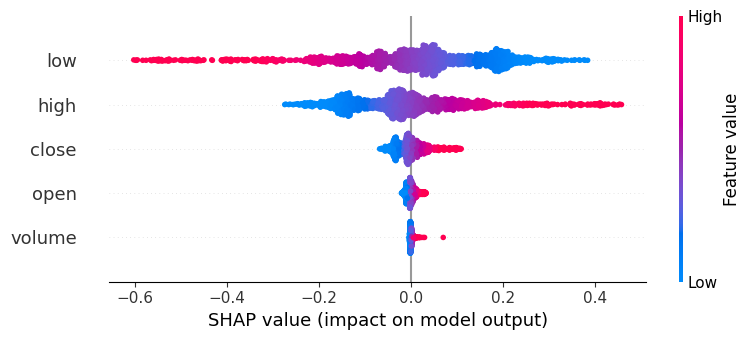

In [11]:
explainer = shap.LinearExplainer(lr, X_train_scaled)
shap_values = explainer.shap_values(X_train_scaled)

shap.summary_plot(shap_values, X_train_scaled, feature_names=X_train.columns)

In [12]:
y_pred = lr.predict(X_test_scaled)

In [13]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_lr = mean_absolute_error(y_test, y_pred)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred))
r2_lr = r2_score(y_test, y_pred)

print("Linear Regression Performance:")
print("MAE :", mae_lr)
print("RMSE:", rmse_lr)
print("R²  :", r2_lr)

Linear Regression Performance:
MAE : 0.010031393632054396
RMSE: 0.01264523462745183
R²  : -1.5280161745875906


In [14]:
# data.loc[X_test.index, "lr_pred"] = y_pred

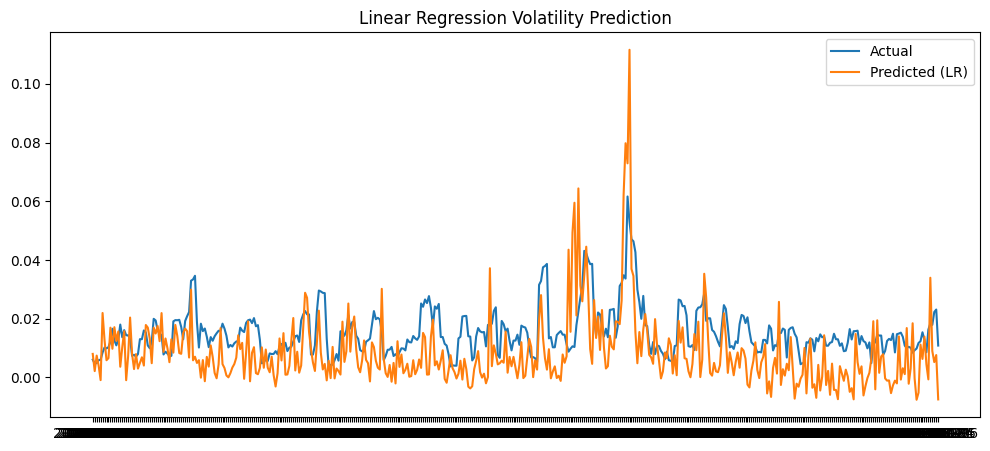

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(y_test.index, y_test, label="Actual")
plt.plot(y_test.index, y_pred, label="Predicted (LR)")
plt.legend()
plt.title("Linear Regression Volatility Prediction")
plt.show()

In [16]:
data.sort_index(ascending=False).head()

,0QKI.LON,0QLR.LON,NSRGY,RHO6.FRK,ABBNY,0QP2.LON,0QKY.LON,0QNO.LON,0QPS.LON,0Z4C.LON,...,US5Y,US10Y,US30Y,YC_Slope,Stress Index,FEDFUNDS,UNRATE,Median CPI,UMCSENT,USEPUINDXD
timestamp,,,,,,,,,,,,,,,,,,,,,
2025-11-26,581.6965,104.8216,98.64,41.685,70.39,574.2851,74.4687,541.0258,3342.334,158.5933,...,3.55,4.01,4.67,0.55,-0.5071,4.09,4.4,2.384737,53.6,386.20
2025-11-25,583.2849,104.5367,98.91,41.530,69.13,568.6862,74.5000,538.6921,3322.671,151.6523,...,3.61,4.04,4.68,0.58,-0.5071,4.09,4.4,2.384737,53.6,327.22
2025-11-24,580.5000,103.0000,99.51,41.760,68.56,565.2000,72.2708,534.8000,3347.135,151.9000,...,3.62,4.06,4.71,0.58,-0.5071,4.09,4.4,2.384737,53.6,327.22
2025-11-21,580.5000,101.8550,100.07,41.900,67.79,558.1000,70.4600,534.2808,3309.500,149.3250,...,3.68,4.10,4.73,0.55,-0.5071,4.09,4.4,2.384737,53.6,490.22
2025-11-20,575.7500,99.9250,98.09,42.140,67.56,562.6000,72.1600,530.0000,3261.500,151.4750,...,3.71,4.13,4.75,0.55,-0.5071,4.09,4.4,2.384737,53.6,279.64


## RandomForest Regressor

In [17]:
split = int(len(data) * 0.8)

X_train = X.iloc[:split]
X_test  = X.iloc[split:]

y_train = y.iloc[:split]
y_test  = y.iloc[split:]

In [18]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=None,        # let trees grow fully (you can tune later)
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt",   # good default
    n_jobs=-1,             # use all cores
    random_state=42
)

rf.fit(X_train, y_train)

,n_estimators,500
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [19]:
y_pred_rf = rf.predict(X_test)

In [20]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Performance:")
print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R²  :", r2_rf)

Random Forest Performance:
MAE : 0.005635585713891614
RMSE: 0.008230848624616692
R²  : -0.07106368251200923


In [21]:
# data["rf_pred"] = np.nan
# data.loc[X_test.index, "rf_pred"] = y_pred_rf

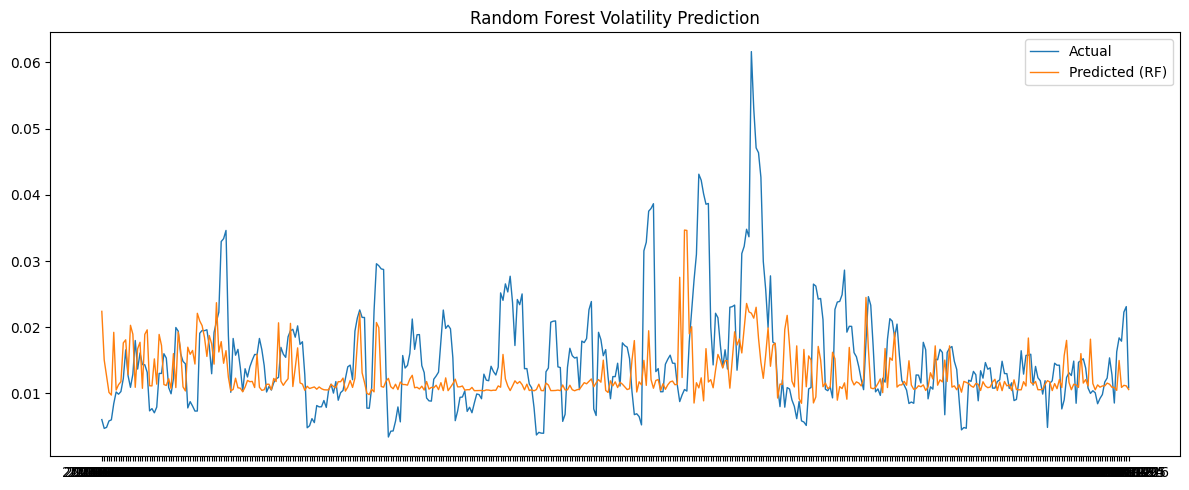

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(y_test.index, y_test, label="Actual", linewidth=1)
plt.plot(y_test.index, y_pred_rf, label="Predicted (RF)", linewidth=1)
plt.legend()
plt.title("Random Forest Volatility Prediction")
plt.tight_layout()
plt.show()

## XGBoost Regressor

In [23]:
split = int(len(data) * 0.8)

X_train = X.iloc[:split]
X_test  = X.iloc[split:]

y_train = y.iloc[:split]
y_test  = y.iloc[split:]

In [24]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [26]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)

xgb.fit(X_train_scaled, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [27]:
y_pred_xgb = xgb.predict(X_test_scaled)

In [28]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

print("XGBoost Performance:")
print("MAE :", mae_xgb)
print("RMSE:", rmse_xgb)
print("R²  :", r2_xgb)

XGBoost Performance:
MAE : 0.005830608813946284
RMSE: 0.008208192899949361
R²  : -0.06517551014188849


In [29]:
# data["xgb_pred"] = np.nan
# data.loc[X_test.index, "xgb_pred"] = y_pred_xgb

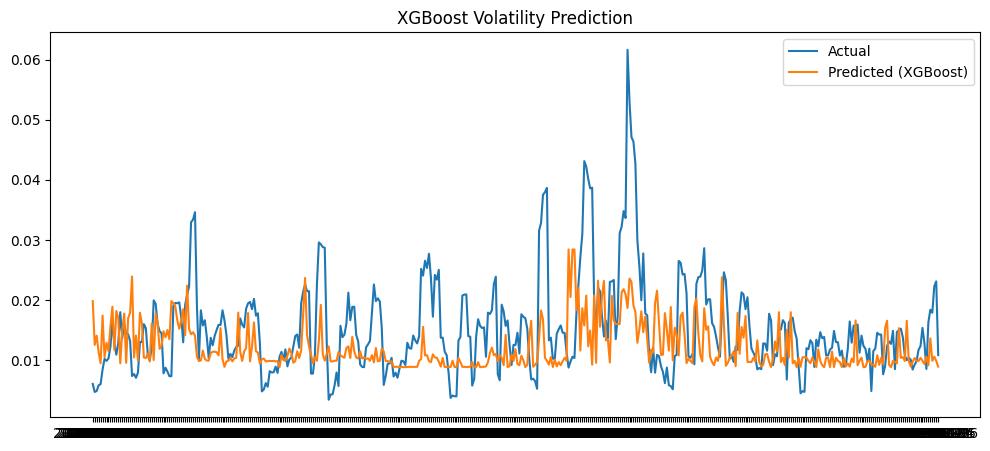

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(y_test.index, y_test, label="Actual")
plt.plot(y_test.index, y_pred_xgb, label="Predicted (XGBoost)")
plt.legend()
plt.title("XGBoost Volatility Prediction")
plt.show()

## LightGBM Regressor

In [31]:
split = int(len(data) * 0.8)

X_train = X.iloc[:split]
X_test  = X.iloc[split:]

y_train = y.iloc[:split]
y_test  = y.iloc[split:]

In [32]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [34]:
from lightgbm import LGBMRegressor

lgbm = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=-1,        # unlimited depth (boosting controls complexity)
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

lgbm.fit(X_train_scaled, y_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000755 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 1720, number of used features: 5
[LightGBM] [Info] Start training from score 0.016312


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.03
,n_estimators,500
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [35]:
y_pred_lgbm = lgbm.predict(X_test_scaled)

c:\Users\staeh\git\stonksai\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [36]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_lgbm = mean_absolute_error(y_test, y_pred_lgbm)
rmse_lgbm = np.sqrt(mean_squared_error(y_test, y_pred_lgbm))
r2_lgbm = r2_score(y_test, y_pred_lgbm)

print("LightGBM Performance:")
print("MAE :", mae_lgbm)
print("RMSE:", rmse_lgbm)
print("R²  :", r2_lgbm)

LightGBM Performance:
MAE : 0.0057156381193587255
RMSE: 0.008403944720487423
R²  : -0.11658666913368543


In [37]:
# data["lgbm_pred"] = np.nan
# data.loc[X_test.index, "lgbm_pred"] = y_pred_lgbm

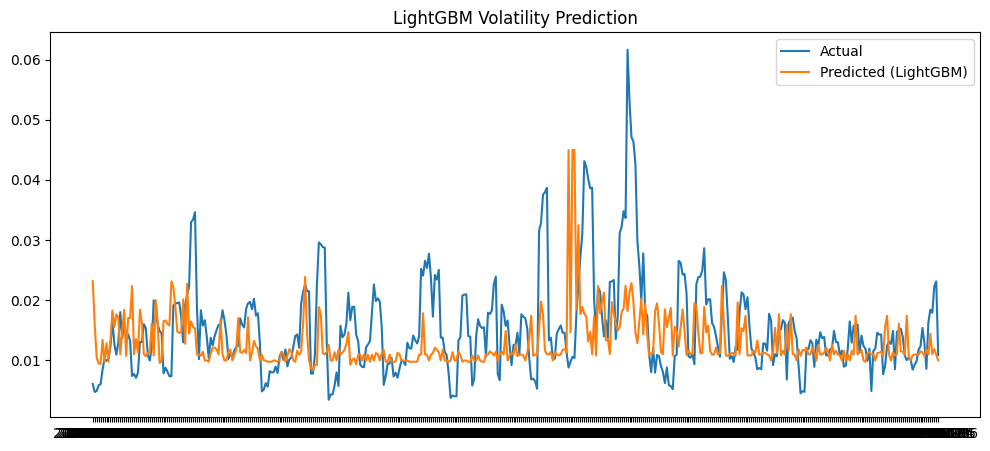

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(y_test.index, y_test, label="Actual")
plt.plot(y_test.index, y_pred_lgbm, label="Predicted (LightGBM)")
plt.legend()
plt.title("LightGBM Volatility Prediction")
plt.show()

## CatBoost

In [39]:
split = int(len(data) * 0.8)

X_train = X.iloc[:split]
X_test  = X.iloc[split:]

y_train = y.iloc[:split]
y_test  = y.iloc[split:]

In [41]:
from catboost import CatBoostRegressor

cat = CatBoostRegressor(
    depth=6,
    learning_rate=0.03,
    loss_function="RMSE",
    n_estimators=500,
    random_seed=42,
    verbose=100
)

cat.fit(X_train, y_train)

0:	learn: 0.0119721	total: 146ms	remaining: 1m 13s
100:	learn: 0.0080539	total: 347ms	remaining: 1.37s
200:	learn: 0.0076399	total: 487ms	remaining: 724ms
300:	learn: 0.0073620	total: 630ms	remaining: 417ms
400:	learn: 0.0071189	total: 773ms	remaining: 191ms
499:	learn: 0.0069147	total: 912ms	remaining: 0us


In [42]:
y_pred_cat = cat.predict(X_test)

In [43]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_cat = mean_absolute_error(y_test, y_pred_cat)
rmse_cat = np.sqrt(mean_squared_error(y_test, y_pred_cat))
r2_cat = r2_score(y_test, y_pred_cat)

print("CatBoost Performance:")
print("MAE :", mae_cat)
print("RMSE:", rmse_cat)
print("R²  :", r2_cat)

CatBoost Performance:
MAE : 0.00536732754592947
RMSE: 0.007764265323235831
R²  : 0.04692560930625023


In [44]:
# data["cat_pred"] = np.nan
# data.loc[X_test.index, "cat_pred"] = y_pred_cat

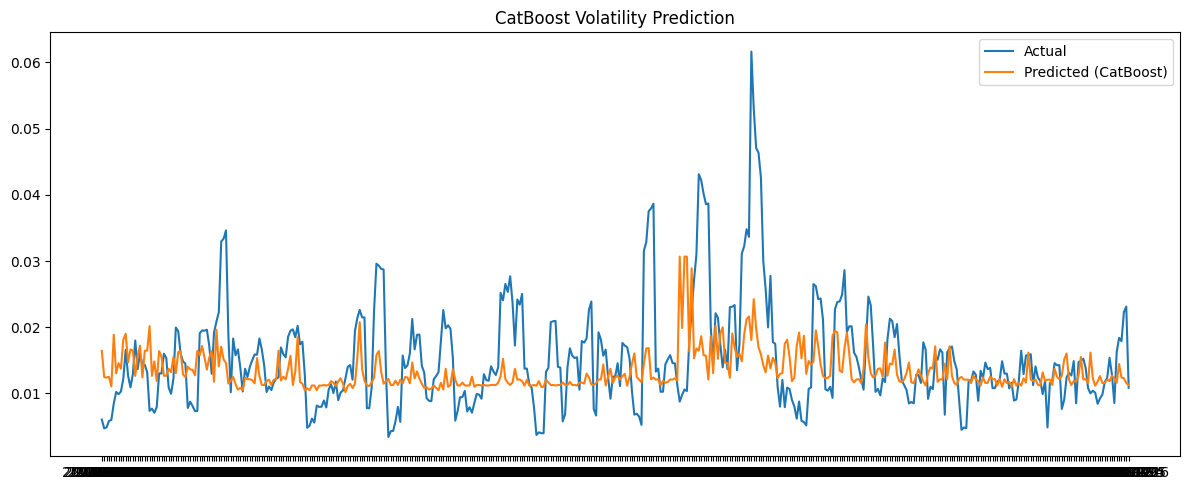

In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(y_test.index, y_test, label="Actual")
plt.plot(y_test.index, y_pred_cat, label="Predicted (CatBoost)")
plt.legend()
plt.title("CatBoost Volatility Prediction")
plt.tight_layout()
plt.show()

## Support Vector Regression (SVR)

In [46]:
split = int(len(data) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

In [47]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [48]:
from sklearn.svm import SVR

svr = SVR(
    kernel="rbf",
    C=1.0,
    epsilon=0.001,
    gamma="scale"
)

svr.fit(X_train_scaled, y_train)


,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,tol,0.001
,C,1.0
,epsilon,0.001
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


In [49]:
y_pred_svr = svr.predict(X_test_scaled)

In [50]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_svr = mean_absolute_error(y_test, y_pred_svr)
rmse_svr = np.sqrt(mean_squared_error(y_test, y_pred_svr))
r2_svr = r2_score(y_test, y_pred_svr)

print("SVR Performance:")
print("MAE :", mae_svr)
print("RMSE:", rmse_svr)
print("R²  :", r2_svr)

SVR Performance:
MAE : 0.016929347124019355
RMSE: 0.022663441606558865
R²  : -7.120406814816905


In [51]:
# data["svr_pred"] = np.nan
# data.loc[X_test.index, "svr_pred"] = y_pred_svr

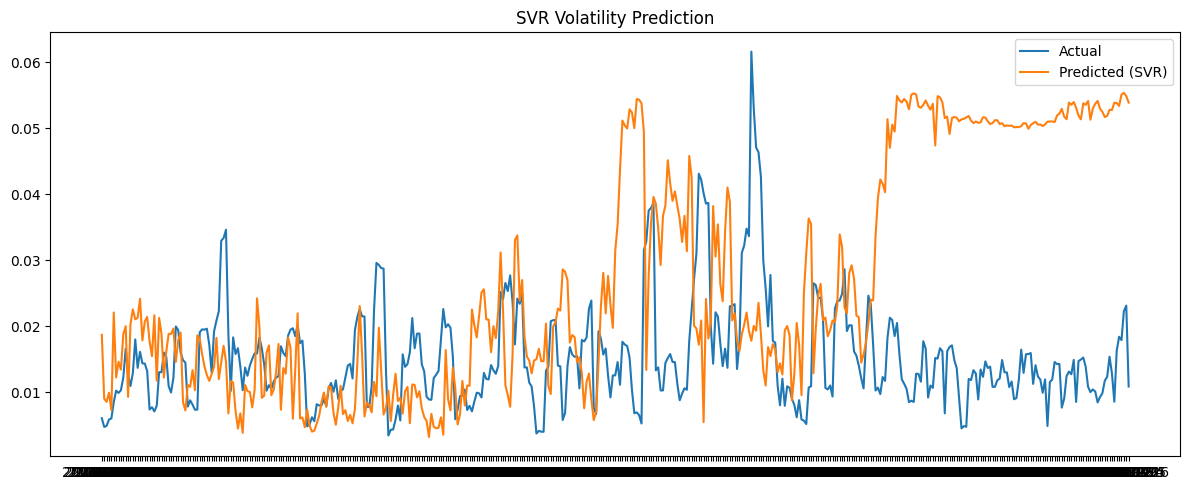

In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(y_test.index, y_test, label="Actual")
plt.plot(y_test.index, y_pred_svr, label="Predicted (SVR)")
plt.legend()
plt.title("SVR Volatility Prediction")
plt.tight_layout()
plt.show()

## ElasticNet Regression

In [53]:
split = int(len(data) * 0.8)

X_train = X.iloc[:split]
X_test  = X.iloc[split:]

y_train = y.iloc[:split]
y_test  = y.iloc[split:]

In [54]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [55]:
from sklearn.linear_model import ElasticNet

elastic = ElasticNet(
    alpha=0.0005,
    l1_ratio=0.5,
    max_iter=5000,
    random_state=42
)

elastic.fit(X_train_scaled, y_train)

,alpha,0.0005
,l1_ratio,0.5
,fit_intercept,True
,precompute,False
,max_iter,5000
,copy_X,True
,tol,0.0001
,warm_start,False
,positive,False
,random_state,42
,selection,'cyclic'


In [56]:
y_pred_elastic = elastic.predict(X_test_scaled)

In [57]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_elastic = mean_absolute_error(y_test, y_pred_elastic)
rmse_elastic = np.sqrt(mean_squared_error(y_test, y_pred_elastic))
r2_elastic = r2_score(y_test, y_pred_elastic)

print("ElasticNet Performance:")
print("MAE :", mae_elastic)
print("RMSE:", rmse_elastic)
print("R²  :", r2_elastic)

ElasticNet Performance:
MAE : 0.009023969184610807
RMSE: 0.011244769564024504
R²  : -0.9990662377547181


In [58]:
# data["elastic_pred"] = np.nan
# data.loc[X_test.index, "elastic_pred"] = y_pred_elastic

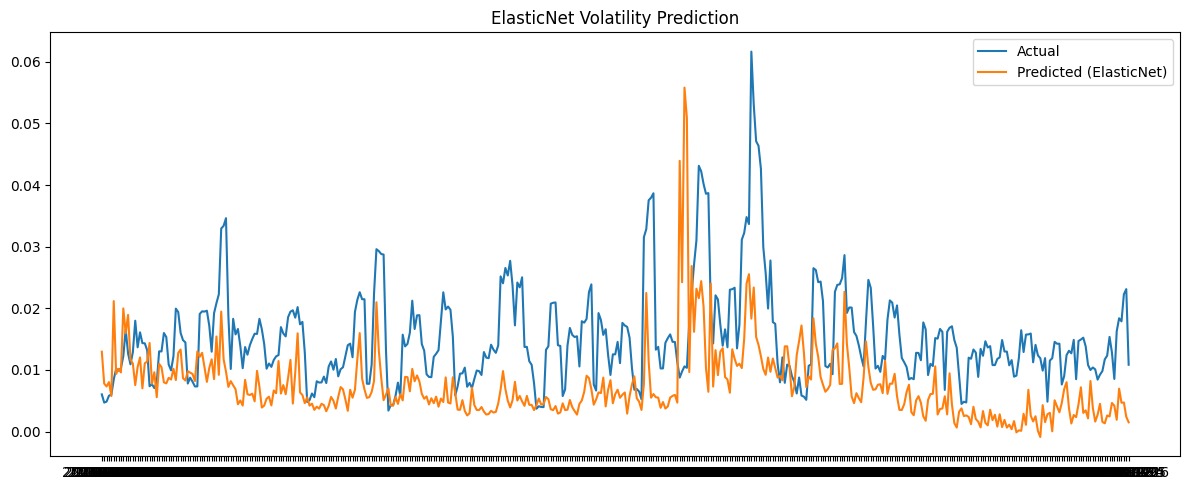

In [59]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(y_test.index, y_test, label="Actual")
plt.plot(y_test.index, y_pred_elastic, label="Predicted (ElasticNet)")
plt.legend()
plt.title("ElasticNet Volatility Prediction")
plt.tight_layout()
plt.show()

## MLP Neural Network (Multi-Layer Perceptron)

In [60]:
split = int(len(data) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

In [61]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [62]:
from sklearn.neural_network import MLPRegressor

mlp = MLPRegressor(
    hidden_layer_sizes=(64, 64),   # two hidden layers with 64 neurons each
    activation='relu',
    solver='adam',
    alpha=0.0001,                  # L2 regularization
    learning_rate='adaptive',
    max_iter=5000,
    random_state=42
)

mlp.fit(X_train_scaled, y_train)

,loss,'squared_error'
,hidden_layer_sizes,"(64, ...)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'adaptive'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,5000
,shuffle,True


In [63]:
y_pred_mlp = mlp.predict(X_test_scaled)

In [64]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_mlp = mean_absolute_error(y_test, y_pred_mlp)
rmse_mlp = np.sqrt(mean_squared_error(y_test, y_pred_mlp))
r2_mlp = r2_score(y_test, y_pred_mlp)

print("MLP Performance:")
print("MAE :", mae_mlp)
print("RMSE:", rmse_mlp)
print("R²  :", r2_mlp)

MLP Performance:
MAE : 0.022188103938938882
RMSE: 0.027780758884185894
R²  : -11.20152951324904


In [65]:
# data["mlp_pred"] = np.nan
# data.loc[X_test.index, "mlp_pred"] = y_pred_mlp

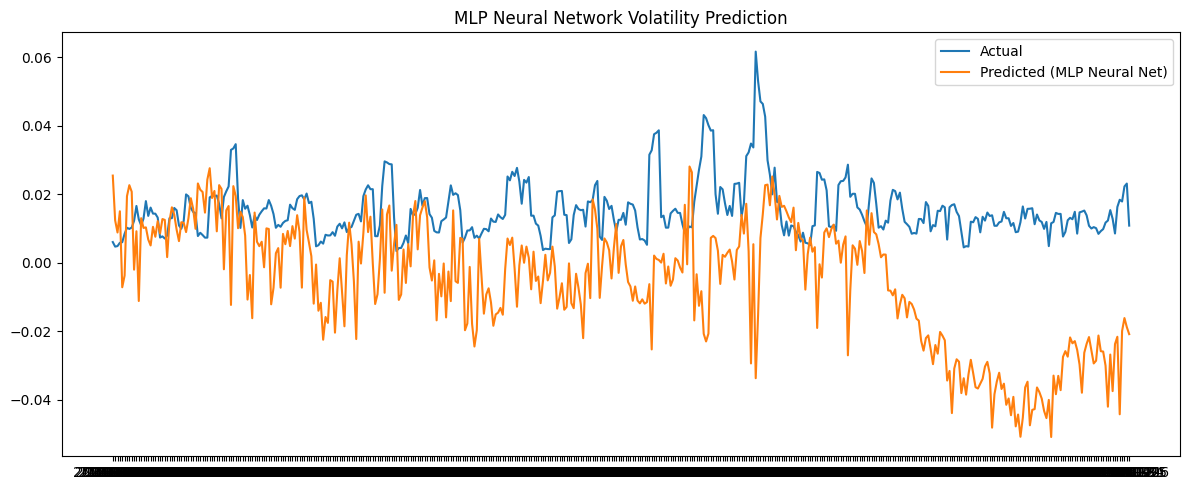

In [66]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(y_test.index, y_test, label="Actual")
plt.plot(y_test.index, y_pred_mlp, label="Predicted (MLP Neural Net)")
plt.legend()
plt.title("MLP Neural Network Volatility Prediction")
plt.tight_layout()
plt.show()

## LSTM

In [67]:
split_idx = int(len(data) * 0.8)

X_train_df = X.iloc[:split_idx]
X_test_df  = X.iloc[split_idx:]

y_train_arr = y[:split_idx]
y_test_arr  = y[split_idx:]

In [68]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_df)
X_test_scaled  = scaler.transform(X_test_df)

In [69]:
lookback = 20  # number of past days in each sequence

def create_sequences(X, y, window):
    Xs, ys = [], []
    for i in range(window, len(X)):
        Xs.append(X[i-window:i])
        ys.append(y[i])
    return np.array(Xs), np.array(ys)

# Training sequences
X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_arr, lookback)

# Test sequences
X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test_arr, lookback)

X_train_seq.shape, X_test_seq.shape

C:\Users\staeh\AppData\Local\Temp\ipykernel_24848\2354788988.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ys.append(y[i])


((1700, 20, 5), (411, 20, 5))

In [71]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

n_features = X_train_seq.shape[2]

model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(lookback, n_features)),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(1)
])

model.compile(
    loss="mse",
    optimizer="adam"
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

c:\Users\staeh\git\stonksai\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [72]:
history = model.fit(
    X_train_seq, y_train_seq,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - loss: 0.0023 - val_loss: 2.6956e-04
Epoch 2/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 6.3017e-04 - val_loss: 3.5104e-04
Epoch 3/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 4.5283e-04 - val_loss: 2.9493e-04
Epoch 4/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 3.3003e-04 - val_loss: 2.3274e-04
Epoch 5/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 3.0167e-04 - val_loss: 0.0011
Epoch 6/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 2.9925e-04 - val_loss: 1.5961e-04
Epoch 7/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 2.1614e-04 - val_loss: 1.8037e-04
Epoch 8/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.8728e-04 - val_loss: 1.5385e-04
Epoch 9/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 1.9327e-04 - val_loss: 1.3718e-04
Epoch 10/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.7563e-04 - val_loss: 2.3562e-04
Epoch 11/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.7477

In [73]:
y_pred_lstm = model.predict(X_test_seq).flatten()

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


In [74]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_lstm = mean_absolute_error(y_test_seq, y_pred_lstm)
rmse_lstm = np.sqrt(mean_squared_error(y_test_seq, y_pred_lstm))
r2_lstm = r2_score(y_test_seq, y_pred_lstm)

print("LSTM Performance:")
print("MAE :", mae_lstm)
print("RMSE:", rmse_lstm)
print("R²  :", r2_lstm)

LSTM Performance:
MAE : 0.0061552935541805435
RMSE: 0.00843849152830884
R²  : -0.10102964589375585


In [75]:
# Indices corresponding to the test sequences
test_index = X_test_df.index[lookback:]  # skip the first `lookback` days

# data["lstm_pred"] = np.nan
# data.loc[test_index, "lstm_pred"] = y_pred_lstm


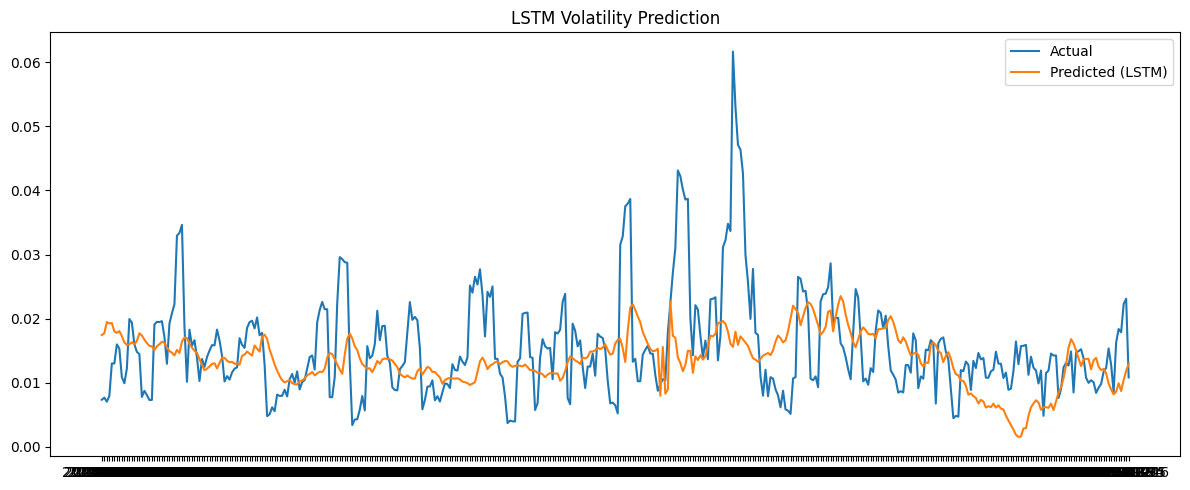

In [76]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(test_index, y_test_seq, label="Actual")
plt.plot(test_index, y_pred_lstm, label="Predicted (LSTM)")
plt.legend()
plt.title("LSTM Volatility Prediction")
plt.tight_layout()
plt.show()

## Chronos 2 Example

In [77]:
import pandas as pd  # requires: pip install 'pandas[pyarrow]'
from chronos import Chronos2Pipeline

pipeline = Chronos2Pipeline.from_pretrained("amazon/chronos-2", device_map="cpu")

# Load historical target values and past values of covariates
context_df = pd.read_parquet("https://autogluon.s3.amazonaws.com/datasets/timeseries/electricity_price/train.parquet")

# (Optional) Load future values of covariates
test_df = pd.read_parquet("https://autogluon.s3.amazonaws.com/datasets/timeseries/electricity_price/test.parquet")
future_df = test_df.drop(columns="target")

# Generate predictions with covariates
pred_df = pipeline.predict_df(
    context_df,
    future_df=future_df,
    prediction_length=24,  # Number of steps to forecast
    quantile_levels=[0.1, 0.5, 0.9],  # Quantile for probabilistic forecast
    id_column="id",  # Column identifying different time series
    timestamp_column="timestamp",  # Column with datetime information
    target="target",  # Column(s) with time series values to predict
)

c:\Users\staeh\git\stonksai\.venv\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


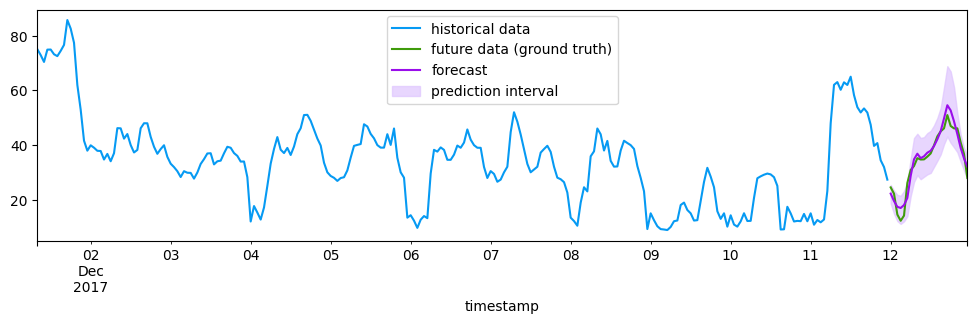

In [78]:
import matplotlib.pyplot as plt  # requires: pip install matplotlib

ts_context = context_df.set_index("timestamp")["target"].tail(256)
ts_pred = pred_df.set_index("timestamp")
ts_ground_truth = test_df.set_index("timestamp")["target"]

ts_context.plot(label="historical data", color="xkcd:azure", figsize=(12, 3))
ts_ground_truth.plot(label="future data (ground truth)", color="xkcd:grass green")
ts_pred["predictions"].plot(label="forecast", color="xkcd:violet")
plt.fill_between(
    ts_pred.index,
    ts_pred["0.1"],
    ts_pred["0.9"],
    alpha=0.7,
    label="prediction interval",
    color="xkcd:light lavender",
)
plt.legend()

## Chronos 2 Zero Shot Univariate

In [79]:
import pandas as pd
import numpy as np

# Ensure sorted by time
data = data.sort_index()

# Use only valid target points
series = data[target_col].dropna()

# Remove any duplicate timestamps just in case
series = series[~series.index.duplicated()]

# Force a regular Business Day frequency (B)
# This creates a regular calendar and fills missing business days with NaN
series = series.asfreq("B")

# Optionally forward-fill for any internal missing days (you can also choose not to)
series = series.ffill()

series = series.astype("float32")


In [80]:
chronos_df = series.to_frame(name="target").reset_index()
chronos_df = chronos_df.rename(columns={"index": "timestamp"})  # if needed

chronos_df["id"] = "ubs"  # name the series

chronos_df = chronos_df[["id", "timestamp", "target"]]
chronos_df.sort_index(ascending=False).head()


,id,timestamp,target
2790,ubs,2025-11-26,NaN
2789,ubs,2025-11-25,NaN
2788,ubs,2025-11-24,NaN
2787,ubs,2025-11-21,NaN
2786,ubs,2025-11-20,NaN


In [81]:
n = len(chronos_df)
split_idx = int(n * 0.8)

train_df = chronos_df.iloc[:split_idx].copy()
test_df  = chronos_df.iloc[split_idx:].copy()

prediction_length = len(test_df)
print(prediction_length)


559


In [82]:
from chronos import Chronos2Pipeline
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

pipeline = Chronos2Pipeline.from_pretrained(
    "amazon/chronos-2",
    device_map=device,
)

# Model ID	                Parameters
# amazon/chronos-2	        120M
# amazon/chronos-bolt-tiny	9M
# amazon/chronos-bolt-mini	21M
# amazon/chronos-bolt-small	48M
# amazon/chronos-bolt-base	205M
# amazon/chronos-t5-tiny	8M
# amazon/chronos-t5-mini	20M
# amazon/chronos-t5-small	46M
# amazon/chronos-t5-base	200M
# amazon/chronos-t5-large	710M

pred_df = pipeline.predict_df(
    df=train_df,
    prediction_length=prediction_length,
    quantile_levels=[0.1, 0.5, 0.9],
    id_column="id",
    timestamp_column="timestamp",
    target="target",
)


c:\Users\staeh\git\stonksai\.venv\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


In [83]:
# Ground truth for the last 20% of the series
y_test = test_df.set_index("timestamp")["target"]

# Chronos predictions
pred_df = pred_df.set_index("timestamp")
y_pred_chronos = pred_df["predictions"].reindex(y_test.index)


In [84]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_chronos_zero_uni = mean_absolute_error(y_test, y_pred_chronos)
rmse_chronos_zero_uni = np.sqrt(mean_squared_error(y_test, y_pred_chronos))
r2_chronos_zero_uni = r2_score(y_test, y_pred_chronos)

print("Chronos 2 (univariate target) Performance:")
print("MAE :", mae_chronos_zero_uni)
print("RMSE:", rmse_chronos_zero_uni)
print("R²  :", r2_chronos_zero_uni)


ValueError: Input contains NaN.

In [ ]:
# data["chronos2_pred"] = np.nan
# data.loc[y_test.index, "chronos2_pred"] = y_pred_chronos.values


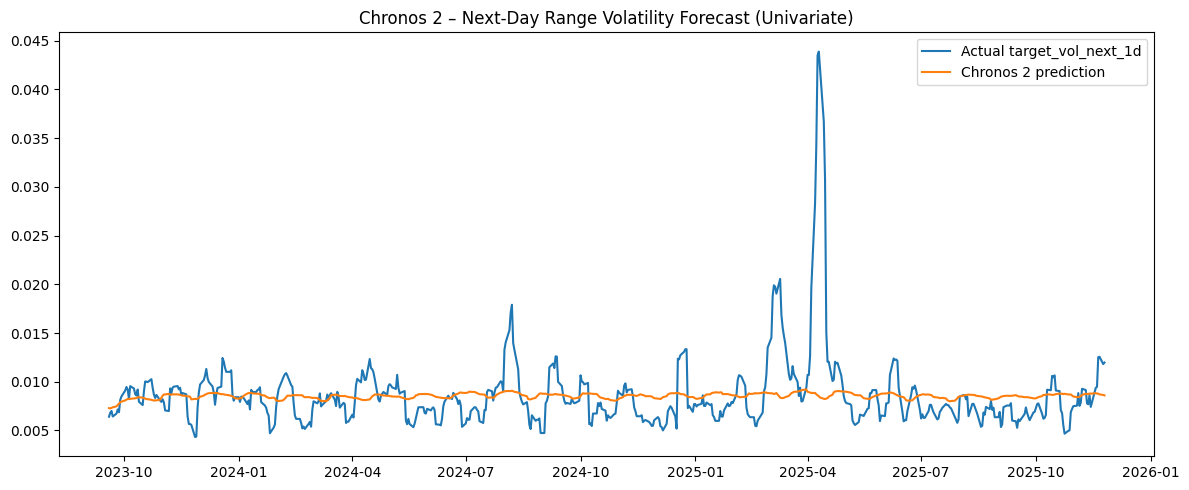

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(y_test.index, y_test, label="Actual target_vol_next_1d")
plt.plot(y_test.index, y_pred_chronos, label="Chronos 2 prediction")
plt.legend()
plt.title("Chronos 2 – Next-Day Range Volatility Forecast (Univariate)")
plt.tight_layout()
plt.show()


## Chronos 2 Zero Shot Multi Covariate

In [ ]:
data.columns

Index(['0QKI.LON', '0QLR.LON', 'NSRGY', 'RHO6.FRK', 'ABBNY', '0QP2.LON',
       '0QKY.LON', '0QNO.LON', '0QPS.LON', '0A0D.LON',
       ...
       'US5Y', 'US10Y', 'US30Y', 'YC_Slope', 'Stress Index', 'FEDFUNDS',
       'UNRATE', 'Median CPI', 'UMCSENT', 'USEPUINDXD'],
      dtype='object', length=142)

In [ ]:
#features = [
#    "open", "high", "low", "close", "volume",
#    "SMA", "EMA", "RSI", "ATR",
#    "Real Lower Band", "Real Middle Band", "Real Upper Band",
#    "range_t"
#]

#target_col = "target_vol_next_1d"

#df_multi = data[features + [target_col]].dropna().sort_index()

In [ ]:
#cols_to_drop = ['FEDERAL_FUNDS_RATE', 'INFLATION', 'REAL_GDP', 'REAL_GDP_PER_CAPITA', 'TREASURY_YIELD', 'CPI', 'FTSE_100', 'SP500', 'EUROSTOXX_50', 'VIX',	'CHFUSD',	'EURUSD',	'US1Y',	'US2Y','US5Y', 'US10Y', 'US30Y', 'YC_Slope', 'Stress Index', 'FEDFUNDS',
#       'UNRATE', 'Median CPI', 'UMCSENT', 'USEPUINDXD']

#df_multi = data.drop(columns=cols_to_drop).dropna().sort_index()

In [ ]:
df_multi = X.merge(y, left_index=True, right_index=True, how="left")

In [ ]:
df_multi.head()

,open,high,low,close,volume,ctc_vol_shifted
timestamp,,,,,,
2019-04-17,13.28,13.3400,13.215,13.33,2352295,0.008704
2019-04-18,13.28,13.3200,13.210,13.26,2737381,0.009328
2019-06-20,11.80,11.8162,11.670,11.76,2447779,0.010559
2019-06-26,11.65,11.7100,11.615,11.68,1638417,0.010067
2019-06-27,11.91,11.9900,11.835,11.84,2311096,0.007845


In [ ]:
df_multi = df_multi[~df_multi.index.duplicated()]

# force business-day frequency
df_multi = df_multi.asfreq("B").ffill()

In [ ]:
chronos_df = df_multi.reset_index()
chronos_df = chronos_df.rename(columns={"index": "timestamp"})

chronos_df["id"] = "ubs"

# reorder columns: id | timestamp | target | features...
#chronos_df = chronos_df[["id", "timestamp", target_col] + features]

In [ ]:
chronos_df = df_multi.reset_index()
chronos_df = chronos_df.rename(columns={"index": "timestamp"})

chronos_df["id"] = "ubs"

# reorder columns: id | timestamp | target | features...
#chronos_df = chronos_df[["id", "timestamp", target_col] + features]

In [ ]:
n = len(chronos_df)
split_idx = int(n * 0.99)

train_df = chronos_df.iloc[:split_idx].copy()
test_df  = chronos_df.iloc[split_idx:].copy()

prediction_length = len(test_df)
print(prediction_length)

18


In [ ]:
from chronos import Chronos2Pipeline
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

pipeline = Chronos2Pipeline.from_pretrained(
    "amazon/chronos-2",
    device_map=device
)

pred_df = pipeline.predict_df(
    df=train_df,
    prediction_length=prediction_length,
    id_column="id",
    timestamp_column="timestamp",
    target=target_col,
    quantile_levels=[0.1, 0.5, 0.9]
)

ModuleNotFoundError: No module named 'chronos'

In [ ]:
# true values
y_test = test_df.set_index("timestamp")[target_col]

# predictions
pred_df = pred_df.set_index("timestamp")
y_pred_chronos_multi = pred_df["predictions"].reindex(y_test.index)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_chronos_zero_multi = mean_absolute_error(y_test, y_pred_chronos_multi)
rmse_chronos_zero_multi = np.sqrt(mean_squared_error(y_test, y_pred_chronos_multi))
r2_chronos_zero_multi = r2_score(y_test, y_pred_chronos_multi)

print("Chronos 2 Multivariate Performance:")
print("MAE :", mae_chronos_zero_multi)
print("RMSE:", rmse_chronos_zero_multi)
print("R²  :", r2_chronos_zero_multi)

Chronos 2 Multivariate Performance:
MAE : 0.0016333633930913304
RMSE: 0.0021516756973835173
R²  : -0.061730119470182254


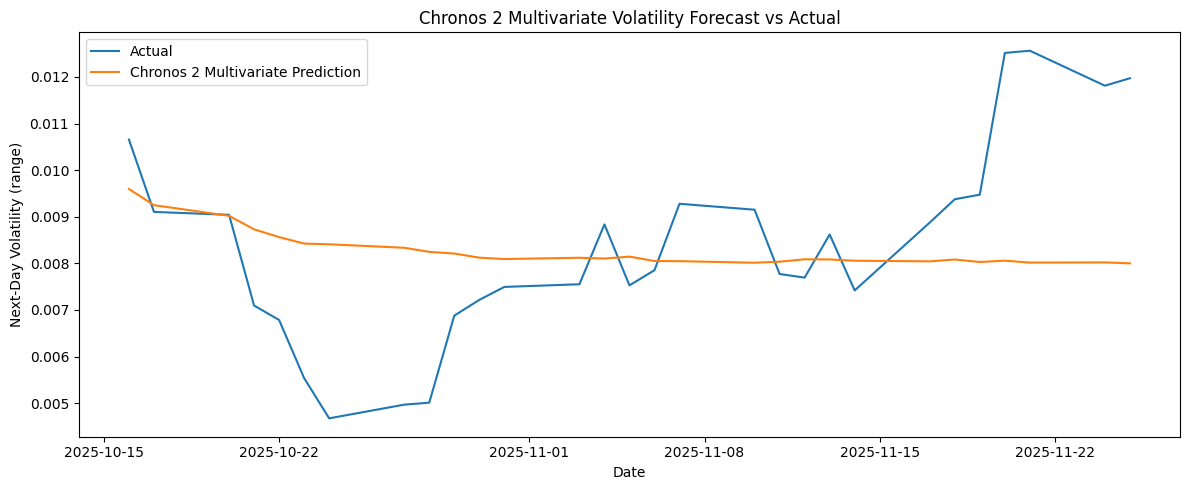

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(y_test.index, y_test, label="Actual")
plt.plot(y_test.index, y_pred_chronos_multi, label="Chronos 2 Multivariate Prediction")
plt.title("Chronos 2 Multivariate Volatility Forecast vs Actual")
plt.xlabel("Date")
plt.ylabel("Next-Day Volatility (range)")
plt.legend()
plt.tight_layout()
plt.show()


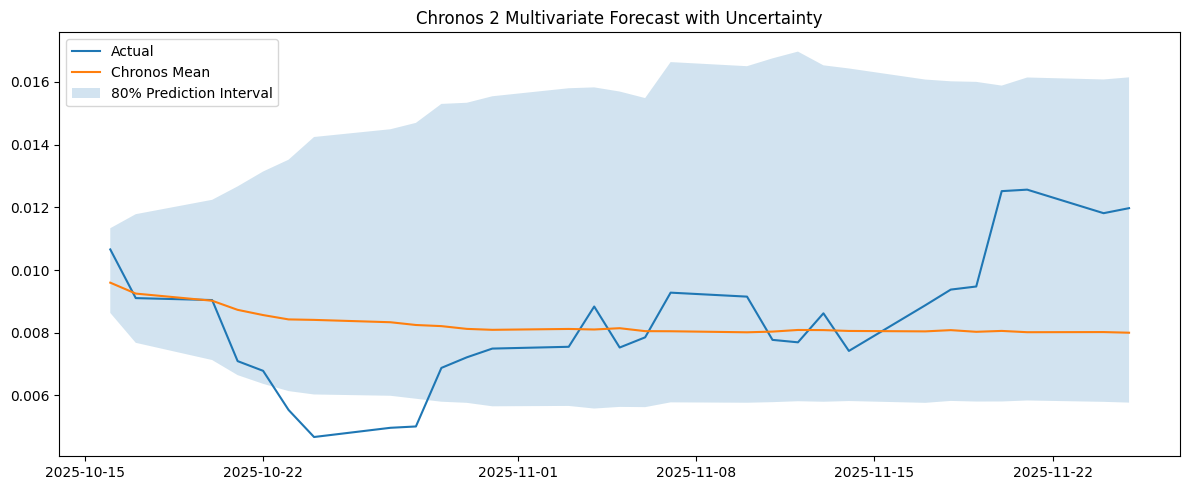

In [ ]:
q10 = pred_df["0.1"].reindex(y_test.index)
q90 = pred_df["0.9"].reindex(y_test.index)

plt.figure(figsize=(12,5))
plt.plot(y_test.index, y_test, label="Actual")
plt.plot(y_test.index, y_pred_chronos_multi, label="Chronos Mean")
plt.fill_between(y_test.index, q10, q90, alpha=0.2, label="80% Prediction Interval")
plt.title("Chronos 2 Multivariate Forecast with Uncertainty")
plt.legend()
plt.tight_layout()
plt.show()


## Comparison

In [86]:
import pandas as pd

results = pd.DataFrame([
    ["Linear Regression", mae_lr,       rmse_lr,       r2_lr],
    ["Random Forest",     mae_rf,       rmse_rf,       r2_rf],
    ["XGBoost",           mae_xgb,      rmse_xgb,      r2_xgb],
    ["LightGBM",          mae_lgbm,     rmse_lgbm,     r2_lgbm],
    ["CatBoost",          mae_cat,      rmse_cat,      r2_cat],
    ["SVR",               mae_svr,      rmse_svr,      r2_svr],
    ["ElasticNet",        mae_elastic,  rmse_elastic,  r2_elastic],
    ["MLP",               mae_mlp,      rmse_mlp,      r2_mlp],
    ["LSTM",              mae_lstm,     rmse_lstm,     r2_lstm],
    #["Chronos2 Zero Uni", mae_chronos_zero_uni,     rmse_chronos_zero_uni,     r2_chronos_zero_uni],
    #["Chronos2 Zero Multi", mae_chronos_zero_multi,     rmse_chronos_zero_multi,     r2_chronos_zero_multi],
], columns=["Model", "MAE", "RMSE", "R2"])

# Sort by R² descending (best at top)
results_sorted = results.sort_values("R2", ascending=False).reset_index(drop=True)

# Round for nicer display
results_sorted[["MAE", "RMSE", "R2"]] = results_sorted[["MAE", "RMSE", "R2"]].round(6)

print(results_sorted)


               Model       MAE      RMSE         R2
0           CatBoost  0.005367  0.007764   0.046926
1            XGBoost  0.005831  0.008208  -0.065176
2      Random Forest  0.005636  0.008231  -0.071064
3               LSTM  0.006155  0.008438  -0.101030
4           LightGBM  0.005716  0.008404  -0.116587
5         ElasticNet  0.009024  0.011245  -0.999066
6  Linear Regression  0.010031  0.012645  -1.528016
7                SVR  0.016929  0.022663  -7.120407
8                MLP  0.022188  0.027781 -11.201530


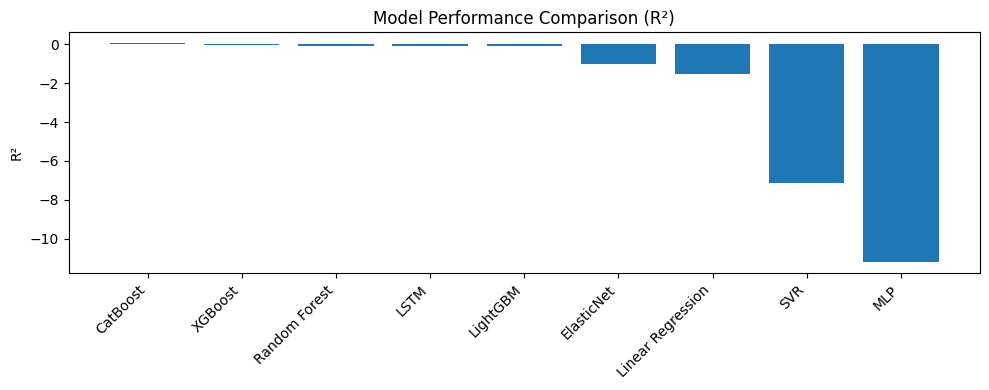

In [87]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.bar(results_sorted["Model"], results_sorted["R2"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("R²")
plt.title("Model Performance Comparison (R²)")
plt.tight_layout()
plt.show()